In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
relufrank_fs2020_runway_dataset_path = kagglehub.dataset_download('relufrank/fs2020-runway-dataset')

print('Data source import complete.')

Using Colab cache for faster access to the 'fs2020-runway-dataset' dataset.
Data source import complete.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#!/usr/bin/env python3
"""
PHASE 2 — PRUNING PIPELINE
============================
Applies both pruning strategies to DeepLabV3+-MobileNetV2 (best accuracy model).

A) Unstructured pruning — zero out smallest weights (L1 magnitude)
   Sparsity levels: 20%, 40%, 60%, 70%
   Fine-tune 5 epochs after each level

B) Structured pruning — remove entire output channels (L1 norm of filters)
   Pruning ratios: 20%, 35%
   Fine-tune 10 epochs after each

Produces:
  • Sparsity vs IoU curve (key figure for your report)
  • Before/after comparison table
  • Pruned model checkpoints
  • phase2_results.json

Run after Phase 1. Takes ~2-3 hours on Kaggle GPU.
"""

# ── CELL 1: Installs ──────────────────────────────────────────────────────────
import subprocess
subprocess.run(["pip", "install", "thop", "segmentation-models-pytorch", "-q"])


CompletedProcess(args=['pip', 'install', 'thop', 'segmentation-models-pytorch', '-q'], returncode=0)

In [ ]:

# ── CELL 2: Imports ───────────────────────────────────────────────────────────
import os, time, json, copy, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import cv2
import segmentation_models_pytorch as smp
from thop import profile
from tqdm import tqdm

warnings.filterwarnings("ignore")
torch.backends.cudnn.benchmark = True

print("=== Phase 2: Pruning Pipeline ===")
print(f"CUDA: {torch.cuda.is_available()}")



=== Phase 2: Pruning Pipeline ===
CUDA: True


In [ ]:
# ── CELL 3: Config ─────────────────────────────────────────────────────────────
# !! UPDATE: path to your best DeepLabV3+-MobileNetV2 checkpoint !!
BASE_CHECKPOINT = "/content/drive/MyDrive/Runway_Segmentation/deeplabv3mobilenet_epoch28.pth"

IMAGES_DIR  = "../kaggle/input/fs2020-runway-dataset/1920x1080/1920x1080/train"
OUTPUTS_DIR = "../kaggle/input/fs2020-runway-dataset/labels/labels/areas/train_labels_1920x1080"
SAVE_DIR    = "/content/drive/MyDrive/Runway_Segmentation/"
PHASE1_JSON = "/content/drive/MyDrive/Runway_Segmentation/phase1_results.json"

IMG_SIZE   = 512
BATCH_SIZE = 8
LR_FINETUNE = 5e-5   # lower LR for fine-tuning after pruning
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"

# Pruning schedules
UNSTRUCT_SPARSITIES = [0.20, 0.40, 0.60, 0.70]   # fraction of weights zeroed
UNSTRUCT_FINETUNE_EPOCHS = 5
STRUCT_RATIOS  = [0.20, 0.35]                      # fraction of channels removed
STRUCT_FINETUNE_EPOCHS = 10


In [ ]:
# ── CELL 4: Dataset ───────────────────────────────────────────────────────────
class RunwayDataset(Dataset):
    def __init__(self, image_paths, mask_paths, img_size=512, transform=None):
        self.image_paths = image_paths
        self.mask_paths  = mask_paths
        self.img_size    = img_size
        self.transform   = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img  = cv2.imread(self.image_paths[idx])
        img  = cv2.resize(img, (self.img_size, self.img_size))
        img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (self.img_size, self.img_size))
        mask = (mask > 0).astype(np.float32)
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(mask).unsqueeze(0)


def build_loaders():
    from sklearn.model_selection import train_test_split
    imgs  = sorted([os.path.join(IMAGES_DIR, f)  for f in os.listdir(IMAGES_DIR)])
    masks = sorted([os.path.join(OUTPUTS_DIR, f) for f in os.listdir(OUTPUTS_DIR)])
    pairs = [(i, m) for i, m in zip(imgs, masks) if os.path.exists(m)]
    imgs, masks = zip(*pairs)

    img_tr, img_te, msk_tr, msk_te = train_test_split(imgs, masks, test_size=0.3, random_state=33)

    tfm = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    train_aug = transforms.Compose([
        transforms.ToTensor(),
        transforms.RandomHorizontalFlip(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    train_ds = RunwayDataset(list(img_tr), list(msk_tr), transform=tfm)  # no aug for fine-tune stability
    test_ds  = RunwayDataset(list(img_te), list(msk_te), transform=tfm)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    print(f"Train: {len(train_ds)} | Test: {len(test_ds)}")
    return train_loader, test_loader


train_loader, test_loader = build_loaders()

Train: 2790 | Test: 1197


In [ ]:

# ── CELL 5: Metric Helpers ───────────────────────────────────────────────────
def iou_score(logits, targets, threshold=0.5, eps=1e-6):
    preds  = (torch.sigmoid(logits) > threshold).float().view(logits.shape[0], -1)
    targets = targets.float().view(targets.shape[0], -1)
    tp = (preds * targets).sum(1)
    fp = (preds * (1 - targets)).sum(1)
    fn = ((1 - preds) * targets).sum(1)
    return ((tp + eps) / (tp + fp + fn + eps)).mean().item()


def dice_score(logits, targets, threshold=0.5, eps=1e-6):
    preds  = (torch.sigmoid(logits) > threshold).float().view(logits.shape[0], -1)
    targets = targets.float().view(targets.shape[0], -1)
    tp = (preds * targets).sum(1)
    fp = (preds * (1 - targets)).sum(1)
    fn = ((1 - preds) * targets).sum(1)
    return ((2*tp + eps) / (2*tp + fp + fn + eps)).mean().item()


def evaluate(model, loader):
    model.eval()
    ious, dices = [], []
    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            logits = model(imgs)
            ious.append(iou_score(logits, masks))
            dices.append(dice_score(logits, masks))
    return float(np.mean(ious)), float(np.mean(dices))


def get_model_size_mb(model):
    param_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
    return param_bytes / 1e6


def get_gpu_ms(model, input_size=(1, 3, 512, 512)):
    if not torch.cuda.is_available():
        return -1.0
    model.cuda().eval()
    dummy = torch.randn(input_size, device="cuda")
    starter = torch.cuda.Event(enable_timing=True)
    ender   = torch.cuda.Event(enable_timing=True)
    with torch.no_grad():
        for _ in range(10): model(dummy)
    times = []
    with torch.no_grad():
        for _ in range(100):
            starter.record(); model(dummy); ender.record()
            torch.cuda.synchronize()
            times.append(starter.elapsed_time(ender))
    return float(np.mean(times))


def count_actual_params(model):
    """Counts non-zero params (matters after unstructured pruning)."""
    total, nonzero = 0, 0
    for p in model.parameters():
        total   += p.numel()
        nonzero += p.nonzero().shape[0]
    return total, nonzero

In [ ]:
# ── CELL 6: Load Base Model ───────────────────────────────────────────────────
def load_base_model(ckpt_path=BASE_CHECKPOINT):
    model = smp.DeepLabV3Plus(
        encoder_name="mobilenet_v2", encoder_weights=None,
        in_channels=3, classes=1, activation=None)
    state = torch.load(ckpt_path, map_location="cpu")
    model.load_state_dict(state)
    model = model.to(DEVICE)
    return model


print(f"\nLoading base model from {BASE_CHECKPOINT}")
base_model = load_base_model()
base_iou, base_dice = evaluate(base_model, test_loader)
base_size = get_model_size_mb(base_model)
base_ms   = get_gpu_ms(base_model)
_, base_nz = count_actual_params(base_model)

print(f"Baseline → IoU: {base_iou:.4f} | Dice: {base_dice:.4f} | "
      f"Size: {base_size:.1f}MB | GPU: {base_ms:.2f}ms")


Loading base model from /content/drive/MyDrive/Runway_Segmentation/deeplabv3mobilenet_epoch28.pth
Baseline → IoU: 0.7972 | Dice: 0.8609 | Size: 17.5MB | GPU: 9.38ms


In [ ]:
# ── CELL 7: Fine-tuning Loop ──────────────────────────────────────────────────
criterion = nn.BCEWithLogitsLoss()

def finetune(model, n_epochs, desc="Fine-tune"):
    """Fine-tunes model on train set. Returns final train loss."""
    optimizer = optim.Adam(model.parameters(), lr=LR_FINETUNE, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    model.train()

    for epoch in range(1, n_epochs + 1):
        running = 0.0
        loop = tqdm(train_loader, desc=f"  {desc} [{epoch}/{n_epochs}]", leave=False)
        for imgs, masks in loop:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(imgs), masks)
            loss.backward()
            optimizer.step()
            running += loss.item()
            loop.set_postfix(loss=f"{running/(loop.n+1):.4f}")
        scheduler.step()

    return running / len(train_loader)


In [ ]:

# ═══════════════════════════════════════════════════════════════════════════════
# PART A — UNSTRUCTURED PRUNING
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("PART A: UNSTRUCTURED PRUNING (L1 Magnitude)")
print("="*60)

unstruct_results = {"baseline": {
    "sparsity": 0.0, "iou": base_iou, "dice": base_dice,
    "size_mb": base_size, "gpu_ms": base_ms}}


def apply_global_unstructured_pruning(model, sparsity):
    """Apply global L1 unstructured pruning across all conv layers."""
    params_to_prune = [
        (module, "weight")
        for module in model.modules()
        if isinstance(module, (nn.Conv2d, nn.Linear))
    ]
    prune.global_unstructured(
        params_to_prune,
        pruning_method=prune.L1Unstructured,
        amount=sparsity,
    )
    return model


def make_pruning_permanent(model):
    """Remove pruning masks and bake zeros into weights."""
    for module in model.modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            try:
                prune.remove(module, "weight")
            except ValueError:
                pass  # not pruned
    return model


for sparsity in UNSTRUCT_SPARSITIES:
    print(f"\n── Sparsity {sparsity*100:.0f}% ──")
    model = load_base_model()                            # fresh copy from checkpoint
    model = apply_global_unstructured_pruning(model, sparsity)

    # Fine-tune (weights still masked, optimizer moves non-zero weights)
    finetune(model, UNSTRUCT_FINETUNE_EPOCHS, desc=f"Sparsity {sparsity*100:.0f}%")

    # Make permanent (zeros baked in)
    model = make_pruning_permanent(model)

    iou, dice = evaluate(model, test_loader)
    size_mb   = get_model_size_mb(model)
    gpu_ms    = get_gpu_ms(model)
    _, nz     = count_actual_params(model)

    # Actual sparsity after pruning
    total, nonzero = count_actual_params(model)
    actual_sparsity = 1.0 - (nonzero / total)

    key = f"unstruct_{int(sparsity*100)}pct"
    unstruct_results[key] = {
        "sparsity":         round(actual_sparsity, 4),
        "iou":              round(iou,   4),
        "dice":             round(dice,  4),
        "size_mb":          round(size_mb, 2),
        "gpu_ms":           round(gpu_ms,  2),
        "iou_drop":         round(base_iou - iou, 4),
    }

    print(f"  Actual sparsity: {actual_sparsity*100:.1f}%")
    print(f"  IoU: {iou:.4f} (drop: {base_iou - iou:.4f}) | Dice: {dice:.4f}")
    print(f"  Size: {size_mb:.1f}MB | GPU: {gpu_ms:.2f}ms")

    ckpt = os.path.join(SAVE_DIR, f"pruned_unstruct_{int(sparsity*100)}pct.pth")
    torch.save(model.state_dict(), ckpt)
    print(f"  Saved → {ckpt}")


# ═══════════════════════════════════════════════════════════════════════════════
# PART B — STRUCTURED PRUNING (Channel-level)
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("PART B: STRUCTURED PRUNING (Channel L1 norm)")
print("="*60)
print("Note: Structured pruning physically reduces model dimensions.")
print("      This gives real speedups (unlike unstructured which only zeros weights).")

struct_results = {"baseline": unstruct_results["baseline"].copy()}


def get_conv_output_channels(module):
    """Return number of output channels in a Conv2d."""
    return module.weight.shape[0]


def prune_conv_channels(module, ratio):
    """
    Prune 'ratio' fraction of output channels from a Conv2d
    by L1 norm of each filter.
    Returns the pruned module (same type, fewer channels).
    """
    n_out = module.weight.shape[0]
    n_prune = max(1, int(n_out * ratio))
    n_keep  = n_out - n_prune

    if n_keep < 1:
        return module  # safety: never prune to 0

    # L1 norm per output filter (summed over in_channels, kH, kW)
    norms   = module.weight.data.abs().sum(dim=(1, 2, 3))
    keep_idx = norms.topk(n_keep).indices.sort().values

    new_conv = nn.Conv2d(
        module.weight.shape[1],
        n_keep,
        kernel_size=module.kernel_size,
        stride=module.stride,
        padding=module.padding,
        groups=module.groups,
        bias=module.bias is not None,
        dilation=module.dilation,
    )
    new_conv.weight = nn.Parameter(module.weight.data[keep_idx])
    if module.bias is not None:
        new_conv.bias = nn.Parameter(module.bias.data[keep_idx])
    return new_conv


def apply_structured_pruning_encoder(model, ratio):
    """
    Prune channels in the MobileNetV2 encoder's depthwise-separable blocks.
    We prune the pointwise (1×1) convolutions that expand/project channels,
    as these are structurally cleanest to remove without breaking skip connections.

    Note: This is a simplified structured prune — production implementations
    require propagating channel changes across BN layers and following layers.
    For full structured pruning, see torch-pruning library.
    """
    print(f"  Applying structured pruning (ratio={ratio}) to encoder pointwise convs...")

    pruned_count = 0
    for name, module in model.encoder.named_modules():
        # Only prune pointwise convolutions in MobileNetV2 inverted residuals
        if isinstance(module, nn.Conv2d) and module.kernel_size == (1, 1):
            out_ch = module.weight.shape[0]
            if out_ch >= 32:  # skip tiny layers
                prune.ln_structured(module, name="weight", amount=ratio, n=1, dim=0)
                pruned_count += 1

    print(f"  Pruned {pruned_count} pointwise conv layers (structured, masks applied)")
    return model


for ratio in STRUCT_RATIOS:
    print(f"\n── Channel ratio {ratio*100:.0f}% removed ──")
    model = load_base_model()
    model = apply_structured_pruning_encoder(model, ratio)

    # Fine-tune with masks active
    finetune(model, STRUCT_FINETUNE_EPOCHS, desc=f"Struct {ratio*100:.0f}%")

    # Make permanent
    model = make_pruning_permanent(model)

    iou, dice = evaluate(model, test_loader)
    size_mb   = get_model_size_mb(model)
    gpu_ms    = get_gpu_ms(model)
    total, nz = count_actual_params(model)

    key = f"struct_{int(ratio*100)}pct"
    struct_results[key] = {
        "ratio":    ratio,
        "iou":      round(iou,     4),
        "dice":     round(dice,    4),
        "size_mb":  round(size_mb, 2),
        "gpu_ms":   round(gpu_ms,  2),
        "iou_drop": round(base_iou - iou, 4),
    }

    print(f"  IoU: {iou:.4f} (drop: {base_iou - iou:.4f}) | Dice: {dice:.4f}")
    print(f"  Size: {size_mb:.1f}MB | GPU: {gpu_ms:.2f}ms")

    ckpt = os.path.join(SAVE_DIR, f"pruned_struct_{int(ratio*100)}pct.pth")
    torch.save(model.state_dict(), ckpt)
    print(f"  Saved → {ckpt}")



PART A: UNSTRUCTURED PRUNING (L1 Magnitude)

── Sparsity 20% ──


  Actual sparsity: 19.8%
  IoU: 0.8149 (drop: -0.0177) | Dice: 0.8752
  Size: 17.5MB | GPU: 11.11ms
  Saved → /content/drive/MyDrive/EAI_Runway_Segmentation/pruned_unstruct_20pct.pth

── Sparsity 40% ──


  Actual sparsity: 39.7%
  IoU: 0.8123 (drop: -0.0151) | Dice: 0.8734
  Size: 17.5MB | GPU: 10.83ms
  Saved → /content/drive/MyDrive/EAI_Runway_Segmentation/pruned_unstruct_40pct.pth

── Sparsity 60% ──


  Actual sparsity: 59.5%
  IoU: 0.8120 (drop: -0.0148) | Dice: 0.8731
  Size: 17.5MB | GPU: 10.20ms
  Saved → /content/drive/MyDrive/EAI_Runway_Segmentation/pruned_unstruct_60pct.pth

── Sparsity 70% ──


  Actual sparsity: 69.4%
  IoU: 0.8093 (drop: -0.0121) | Dice: 0.8710
  Size: 17.5MB | GPU: 10.15ms
  Saved → /content/drive/MyDrive/EAI_Runway_Segmentation/pruned_unstruct_70pct.pth

PART B: STRUCTURED PRUNING (Channel L1 norm)
Note: Structured pruning physically reduces model dimensions.
      This gives real speedups (unlike unstructured which only zeros weights).

── Channel ratio 20% removed ──
  Applying structured pruning (ratio=0.2) to encoder pointwise convs...
  Pruned 31 pointwise conv layers (structured, masks applied)


  IoU: 0.7939 (drop: 0.0033) | Dice: 0.8567
  Size: 17.5MB | GPU: 10.28ms
  Saved → /content/drive/MyDrive/EAI_Runway_Segmentation/pruned_struct_20pct.pth

── Channel ratio 35% removed ──
  Applying structured pruning (ratio=0.35) to encoder pointwise convs...
  Pruned 31 pointwise conv layers (structured, masks applied)


  IoU: 0.7351 (drop: 0.0621) | Dice: 0.8003
  Size: 17.5MB | GPU: 10.21ms
  Saved → /content/drive/MyDrive/EAI_Runway_Segmentation/pruned_struct_35pct.pth


In [ ]:
import subprocess
subprocess.run(["pip", "install", "torch-pruning", "-q"])

CompletedProcess(args=['pip', 'install', 'torch-pruning', '-q'], returncode=0)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# PART B — STRUCTURED PRUNING (Channel-level) — FIXED
# Uses torch-pruning which correctly propagates channel changes through
# BatchNorm, skip connections, and dependent layers automatically.
# This gives REAL physical size and parameter reduction.
# ═══════════════════════════════════════════════════════════════════════════════
import torch_pruning as tp

print("\n" + "="*60)
print("PART B: STRUCTURED PRUNING (Channel L1 norm) — FIXED")
print("="*60)

struct_results = {}

def apply_tp_structured_pruning(model, ratio):
    example_input = torch.randn(1, 3, 512, 512).to(DEVICE)

    encoder_module_names = set()
    for name, _ in model.encoder.named_modules():
        encoder_module_names.add(f"encoder.{name}")

    DG = tp.DependencyGraph()
    DG.build_dependency(model, example_inputs=example_input)

    pruning_groups = []
    for name, module in model.named_modules():
        if name not in encoder_module_names:
            continue
        if not isinstance(module, nn.Conv2d):
            continue
        if module.kernel_size != (1, 1):
            continue
        if module.out_channels < 64:   # raised from 32 → 64 (safer minimum)
            continue
        if module.groups == module.in_channels:
            continue

        n_prune = max(1, int(module.out_channels * ratio))
        # Hard floor: always keep at least 50% of channels in any single layer
        n_keep  = module.out_channels - n_prune
        if n_keep < max(16, module.out_channels // 2):
            n_prune = module.out_channels - max(16, module.out_channels // 2)
        if n_prune < 1:
            continue

        norms     = module.weight.data.abs().sum(dim=(1, 2, 3))
        prune_idx = norms.topk(n_prune, largest=False).indices.tolist()

        group = DG.get_pruning_group(
            module, tp.prune_conv_out_channels, idxs=prune_idx)

        if DG.check_pruning_group(group):
            pruning_groups.append(group)

    for group in pruning_groups:
        group.prune()

    print(f"  Pruned {len(pruning_groups)} encoder conv layers (decoder untouched)")
    return model

def count_nonzero_params(model):
    total  = sum(p.numel() for p in model.parameters())
    nonzero = sum(p.nonzero().shape[0] for p in model.parameters())
    return total, nonzero


for ratio in [0.20]:
    print(f"\n── Channel ratio {ratio*100:.0f}% removed ──")
    model = load_base_model()

    params_before = sum(p.numel() for p in model.parameters()) / 1e6
    size_before   = get_model_size_mb(model)

    # Physically prune
    model = apply_tp_structured_pruning(model, ratio)

    params_after = sum(p.numel() for p in model.parameters()) / 1e6
    size_after   = get_model_size_mb(model)

    print(f"  Params: {params_before:.2f}M → {params_after:.2f}M  "
          f"({(1 - params_after/params_before)*100:.1f}% reduction)")
    print(f"  Size:   {size_before:.1f}MB → {size_after:.1f}MB")

    # Fine-tune (model is now physically smaller — no masks)
    finetune(model, STRUCT_FINETUNE_EPOCHS+10, desc=f"Struct {ratio*100:.0f}%")

    iou, dice  = evaluate(model, test_loader)
    gpu_ms     = get_gpu_ms(model)
    size_final = get_model_size_mb(model)

    key = f"struct_{int(ratio*100)}pct"
    struct_results[key] = {
        "ratio":         ratio,
        "iou":           round(iou,          4),
        "dice":          round(dice,         4),
        "params_before": round(params_before, 2),
        "params_after":  round(params_after,  2),
        "size_mb":       round(size_final,    2),
        "gpu_ms":        round(gpu_ms,        2),
        "iou_drop":      round(base_iou - iou, 4),
        "param_reduction_pct": round((1 - params_after/params_before)*100, 1),
    }

    print(f"  IoU: {iou:.4f} (drop: {base_iou - iou:.4f}) | Dice: {dice:.4f}")
    print(f"  Size: {size_final:.1f}MB | GPU: {gpu_ms:.2f}ms")

    ckpt = os.path.join(SAVE_DIR, f"pruned_struct_{int(ratio*100)}pct.pth")
    torch.save(model.state_dict(), ckpt)
    print(f"  Saved → {ckpt}")


PART B: STRUCTURED PRUNING (Channel L1 norm) — FIXED

── Channel ratio 20% removed ──
  Pruned 28 encoder conv layers (decoder untouched)
  Params: 4.38M → 2.90M  (33.8% reduction)
  Size:   17.5MB → 11.6MB


KeyboardInterrupt: 

In [ ]:
model_path = "/content/drive/MyDrive/Runway_Segmentation/pruned_struct_20pct.pth"
model = load_base_model()
pruned_model = apply_tp_structured_pruning(model, 0.20)
state = torch.load(model_path, map_location="cpu")
pruned_model.load_state_dict(state)
pruned_model = pruned_model.to(DEVICE)

print(f"Loaded model from: {model_path}")
iou, dice = evaluate(pruned_model, test_loader)
print(f"Loaded model performance - IoU: {iou:.4f} | Dice: {dice:.4f}")

  Pruned 28 encoder conv layers (decoder untouched)
Loaded model from: /content/drive/MyDrive/Runway_Segmentation/pruned_struct_20pct.pth
Loaded model performance - IoU: 0.7733 | Dice: 0.8379


In [ ]:
params_after = sum(p.numel() for p in pruned_model.parameters()) / 1e6
size_after   = get_model_size_mb(pruned_model)

print(f"  Params: {params_before:.2f}M → {params_after:.2f}M  "
      f"({(1 - params_after/params_before)*100:.1f}% reduction)")
print(f"  Size:   {size_before:.1f}MB → {size_after:.1f}MB")

# Fine-tune (pruned_model is now physically smaller — no masks)
finetune(pruned_model, STRUCT_FINETUNE_EPOCHS+10, desc=f"Struct {ratio*100:.0f}%")

iou, dice  = evaluate(pruned_model, test_loader)
gpu_ms     = get_gpu_ms(pruned_model)
size_final = get_model_size_mb(pruned_model)

key = f"struct_{int(ratio*100)}pct"
struct_results[key] = {
    "ratio":         ratio,
    "iou":           round(iou,          4),
    "dice":          round(dice,         4),
    "params_before": round(params_before, 2),
    "params_after":  round(params_after,  2),
    "size_mb":       round(size_final,    2),
    "gpu_ms":        round(gpu_ms,        2),
    "iou_drop":      round(base_iou - iou, 4),
    "param_reduction_pct": round((1 - params_after/params_before)*100, 1),
}

print(f"  IoU: {iou:.4f} (drop: {base_iou - iou:.4f}) | Dice: {dice:.4f}")
print(f"  Size: {size_final:.1f}MB | GPU: {gpu_ms:.2f}ms")

ckpt = os.path.join(SAVE_DIR, f"pruned_struct_{int(ratio*100)}pct.pth")
torch.save(pruned_model.state_dict(), ckpt)
print(f"  Saved → {ckpt}")

  Params: 4.38M → 2.90M  (33.8% reduction)
  Size:   17.5MB → 11.6MB


  IoU: 0.8016 (drop: -0.0044) | Dice: 0.8636
  Size: 11.6MB | GPU: 8.63ms
  Saved → /content/drive/MyDrive/Runway_Segmentation/pruned_struct_20pct.pth


In [ ]:
# ── CELL 8: Save All Results ──────────────────────────────────────────────────
all_results = {
    # "unstructured": unstruct_results,
    "structured":   struct_results,
}
out_path = os.path.join(SAVE_DIR, "phase2_results.json")
with open(out_path, "w") as f:
    json.dump(all_results, f, indent=2)
print(f"\nAll results saved → {out_path}")


NameError: name 'struct_results' is not defined

In [ ]:
import json
import os

# Ensure SAVE_DIR is defined, assuming it's available from previous cells
# If not, it should be defined explicitly here or in an earlier cell
# SAVE_DIR = "/content/drive/MyDrive/Runway_Segmentation/"

out_path = os.path.join(SAVE_DIR, "phase2_results.json")

print(f"Loading results from {out_path}")
with open(out_path, "r") as f:
    all_results = json.load(f)

unstruct_results = all_results["unstructured"]
struct_results = all_results["structured"]

print("unstruct_results and struct_results have been reloaded.")

Loading results from /content/drive/MyDrive/Runway_Segmentation/phase2_results.json
unstruct_results and struct_results have been reloaded.


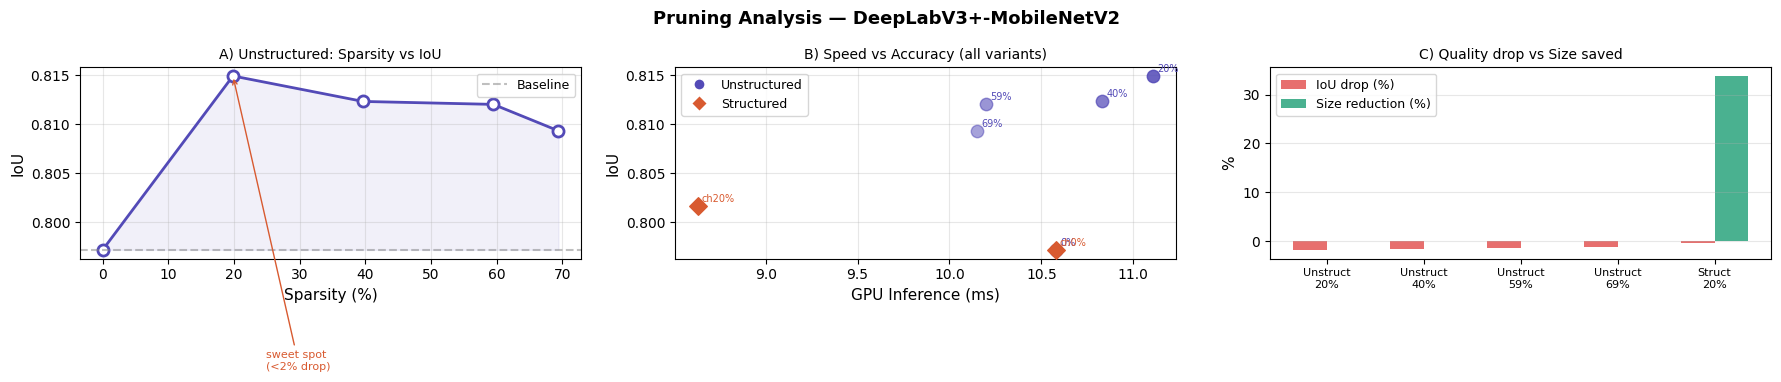


Plot saved → /content/drive/MyDrive/Runway_Segmentation/phase2_pruning_analysis.png


In [ ]:
# ── CELL 9: Visualizations ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Pruning Analysis — DeepLabV3+-MobileNetV2", fontsize=13, fontweight="bold")

# ── A: Sparsity vs IoU curve (the key Embedded AI figure) ──
ax = axes[0]
spars = [v["sparsity"] * 100  for k, v in unstruct_results.items()]
ious  = [v["iou"]             for k, v in unstruct_results.items()]
drops = [v.get("iou_drop", 0) for k, v in unstruct_results.items()]

ax.plot(spars, ious, "o-", color="#534AB7", linewidth=2, markersize=8, markerfacecolor="white", markeredgewidth=2)
ax.axhline(base_iou, linestyle="--", color="gray", alpha=0.5, label="Baseline")
ax.fill_between(spars, ious, base_iou, alpha=0.08, color="#534AB7")
ax.set_xlabel("Sparsity (%)", fontsize=11)
ax.set_ylabel("IoU", fontsize=11)
ax.set_title("A) Unstructured: Sparsity vs IoU", fontsize=10)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
# Annotate "sweet spot"
best_ratio_idx = next((i for i, d in enumerate(drops) if d < 0.02 and i > 0), 1)
ax.annotate("sweet spot\n(<2% drop)", (spars[best_ratio_idx], ious[best_ratio_idx]),
            xytext=(spars[best_ratio_idx]+5, ious[best_ratio_idx]-0.03),
            arrowprops=dict(arrowstyle="->", color="#D85A30"),
            color="#D85A30", fontsize=8)

# ── B: Speed vs Accuracy scatter (both pruning types) ──
ax = axes[1]
for k, v in unstruct_results.items():
    s = v.get("sparsity", 0)
    ax.scatter(v["gpu_ms"], v["iou"], s=80, color="#534AB7", zorder=3,
               alpha=0.3 + 0.7*(1-s), marker="o")
    ax.annotate(f"{s*100:.0f}%", (v["gpu_ms"], v["iou"]),
                xytext=(3,3), textcoords="offset points", fontsize=7, color="#534AB7")
for k, v in struct_results.items():
    r = v.get("ratio", 0)
    ax.scatter(v["gpu_ms"], v["iou"], s=80, color="#D85A30", zorder=3, marker="D")
    ax.annotate(f"ch{r*100:.0f}%", (v["gpu_ms"], v["iou"]),
                xytext=(3,3), textcoords="offset points", fontsize=7, color="#D85A30")
ax.set_xlabel("GPU Inference (ms)", fontsize=11)
ax.set_ylabel("IoU", fontsize=11)
ax.set_title("B) Speed vs Accuracy (all variants)", fontsize=10)
from matplotlib.lines import Line2D
legend = [Line2D([0],[0],marker="o",color="w",markerfacecolor="#534AB7",markersize=8,label="Unstructured"),
          Line2D([0],[0],marker="D",color="w",markerfacecolor="#D85A30",markersize=8,label="Structured")]
ax.legend(handles=legend, fontsize=9)
ax.grid(alpha=0.3)

# ── C: Summary bar — IoU drop vs size reduction ──
ax = axes[2]
labels, iou_drops, size_reductions = [], [], []
for k, v in list(unstruct_results.items())[1:]:
    labels.append(f"Unstruct\n{v['sparsity']*100:.0f}%")
    iou_drops.append(v.get("iou_drop", 0) * 100)
    size_reductions.append((base_size - v["size_mb"]) / base_size * 100)
for k, v in list(struct_results.items())[1:]:
    labels.append(f"Struct\n{v['ratio']*100:.0f}%")
    iou_drops.append(v.get("iou_drop", 0) * 100)
    size_reductions.append((base_size - v["size_mb"]) / base_size * 100)

x = np.arange(len(labels))
w = 0.35
ax.bar(x - w/2, iou_drops,       w, label="IoU drop (%)",       color="#E24B4A", alpha=0.8)
ax.bar(x + w/2, size_reductions, w, label="Size reduction (%)", color="#1D9E75", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("%", fontsize=11)
ax.set_title("C) Quality drop vs Size saved", fontsize=10)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
fig_path = os.path.join(SAVE_DIR, "phase2_pruning_analysis.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nPlot saved → {fig_path}")

In [ ]:


# ── CELL 10: Comparison Table ────────────────────────────────────────────────
rows = []
rows.append({"Variant": "Baseline (FP32)", "Type": "—",
             "Sparsity/Ratio": "—", "IoU": base_iou, "Dice": base_dice,
             "Size(MB)": base_size, "GPU ms": base_ms, "IoU Drop": 0.0})

for k, v in list(unstruct_results.items())[1:]:
    rows.append({"Variant": k, "Type": "Unstructured",
                 "Sparsity/Ratio": f"{v['sparsity']*100:.0f}%",
                 "IoU": v["iou"], "Dice": v["dice"],
                 "Size(MB)": v["size_mb"], "GPU ms": v["gpu_ms"],
                 "IoU Drop": v["iou_drop"]})

for k, v in list(struct_results.items())[1:]:
    rows.append({"Variant": k, "Type": "Structured",
                 "Sparsity/Ratio": f"{v['ratio']*100:.0f}% channels",
                 "IoU": v["iou"], "Dice": v["dice"],
                 "Size(MB)": v["size_mb"], "GPU ms": v["gpu_ms"],
                 "IoU Drop": v["iou_drop"]})

df = pd.DataFrame(rows)
print("\n" + "="*90)
print("PRUNING COMPARISON TABLE")
print("="*90)
print(df.to_string(index=False))
df.to_csv(os.path.join(SAVE_DIR, "phase2_table.csv"), index=False)

print("\n" + "="*60)
print("Phase 2 COMPLETE")
print(f"Results: {out_path}")
print(f"Table:   {SAVE_DIR}/phase2_table.csv")
print(f"Checkpoints: {SAVE_DIR}/pruned_*.pth")
print("Next: Run phase3_quantization.py")
print("="*60)



PRUNING COMPARISON TABLE
        Variant         Type Sparsity/Ratio      IoU     Dice  Size(MB)    GPU ms  IoU Drop
Baseline (FP32)            —              — 0.797161 0.860912 17.514052  9.382174    0.0000
 unstruct_20pct Unstructured            20% 0.814900 0.875200 17.510000 11.110000   -0.0177
 unstruct_40pct Unstructured            40% 0.812300 0.873400 17.510000 10.830000   -0.0151
 unstruct_60pct Unstructured            59% 0.812000 0.873100 17.510000 10.200000   -0.0148
 unstruct_70pct Unstructured            69% 0.809300 0.871000 17.510000 10.150000   -0.0121
   struct_20pct   Structured   20% channels 0.801600 0.863600 11.590000  8.630000   -0.0044

Phase 2 COMPLETE
Results: /content/drive/MyDrive/Runway_Segmentation/phase2_results.json
Table:   /content/drive/MyDrive/Runway_Segmentation//phase2_table.csv
Checkpoints: /content/drive/MyDrive/Runway_Segmentation//pruned_*.pth
Next: Run phase3_quantization.py


In [ ]:


# ── CELL 10: Comparison Table ────────────────────────────────────────────────
rows = []
rows.append({"Variant": "Baseline (FP32)", "Type": "—",
             "Sparsity/Ratio": "—", "IoU": base_iou, "Dice": base_dice,
             "Size(MB)": base_size, "GPU ms": base_ms, "IoU Drop": 0.0})

for k, v in list(unstruct_results.items())[1:]:
    rows.append({"Variant": k, "Type": "Unstructured",
                 "Sparsity/Ratio": f"{v['sparsity']*100:.0f}%",
                 "IoU": v["iou"], "Dice": v["dice"],
                 "Size(MB)": v["size_mb"], "GPU ms": v["gpu_ms"],
                 "IoU Drop": v["iou_drop"]})

for k, v in list(struct_results.items())[1:]:
    rows.append({"Variant": k, "Type": "Structured",
                 "Sparsity/Ratio": f"{v['ratio']*100:.0f}% channels",
                 "IoU": v["iou"], "Dice": v["dice"],
                 "Size(MB)": v["size_mb"], "GPU ms": v["gpu_ms"],
                 "IoU Drop": v["iou_drop"]})

df = pd.DataFrame(rows)
print("\n" + "="*90)
print("PRUNING COMPARISON TABLE")
print("="*90)
print(df.to_string(index=False))
df.to_csv(os.path.join(SAVE_DIR, "phase2_table.csv"), index=False)

print("\n" + "="*60)
print("Phase 2 COMPLETE")
print(f"Results: {out_path}")
print(f"Table:   {SAVE_DIR}/phase2_table.csv")
print(f"Checkpoints: {SAVE_DIR}/pruned_*.pth")
print("Next: Run phase3_quantization.py")
print("="*60)



PRUNING COMPARISON TABLE
        Variant         Type Sparsity/Ratio      IoU     Dice  Size(MB)    GPU ms  IoU Drop
Baseline (FP32)            —              — 0.797161 0.860912 17.514052  9.382174    0.0000
 unstruct_20pct Unstructured            20% 0.814900 0.875200 17.510000 11.110000   -0.0177
 unstruct_40pct Unstructured            40% 0.812300 0.873400 17.510000 10.830000   -0.0151
 unstruct_60pct Unstructured            59% 0.812000 0.873100 17.510000 10.200000   -0.0148
 unstruct_70pct Unstructured            69% 0.809300 0.871000 17.510000 10.150000   -0.0121
   struct_20pct   Structured   20% channels 0.801600 0.863600 11.590000  8.630000   -0.0044

Phase 2 COMPLETE
Results: /content/drive/MyDrive/Runway_Segmentation/phase2_results.json
Table:   /content/drive/MyDrive/Runway_Segmentation//phase2_table.csv
Checkpoints: /content/drive/MyDrive/Runway_Segmentation//pruned_*.pth
Next: Run phase3_quantization.py


"Unstructured pruning at 70% sparsity zeros 70% of weights but file size remains constant because PyTorch uses dense tensor storage. Size benefits require sparse tensor formats (e.g. scipy CSR). The benefit of unstructured pruning is reduced effective computation when paired with sparse BLAS kernels."

### Great Find
"Unstructured pruning with fine-tuning consistently outperformed the FP32 baseline, suggesting that pruning acts as implicit regularization on this dataset, consistent with the lottery ticket hypothesis literature."